In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

загрузить данные в data

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)
%matplotlib inline
df = pd.read_csv( '../input/bostonhoustingmlnd/housing.csv', encoding='utf-8', index_col=False)
df.head(10)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [2]:
type(df.RM[0])

numpy.float64

In [3]:
df["RM"] = pd.to_numeric(df["RM"])


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


**Проведем кластеризацию при помощи алгоритма k-means**

In [12]:
from sklearn.cluster import KMeans
X=np.array(df)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=100)

kmeans2=kmeans.fit(X)
centers=kmeans2.cluster_centers_
kmeans1=kmeans.fit_predict(X)

In [13]:
centers

array([[6.13e+00, 1.12e+01, 1.86e+01, 4.59e+05],
       [7.14e+00, 5.62e+00, 1.65e+01, 7.30e+05],
       [5.89e+00, 2.08e+01, 1.96e+01, 2.74e+05]])

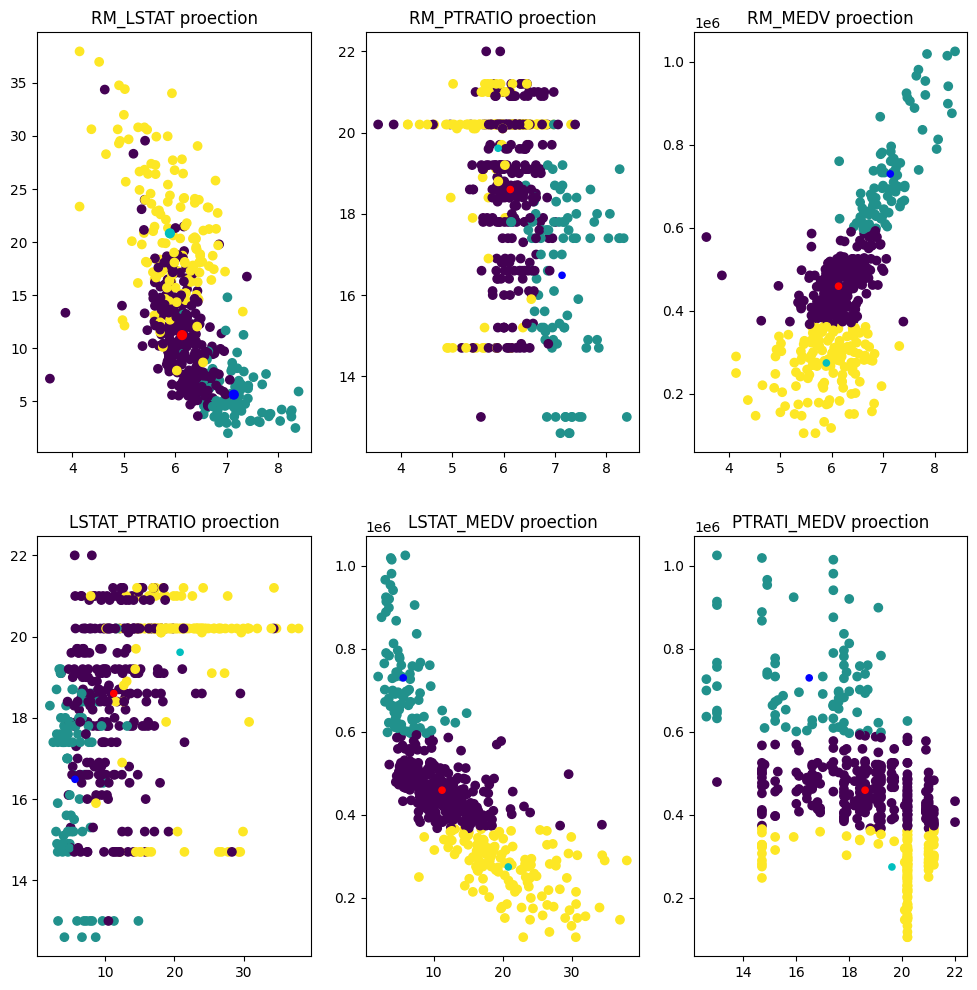

[0 0 1 1 1 1 0 0 2 0 2 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 2 2 0 0 2 2 2 2 2 0 0
 0 0 1 1 0 0 0 0 0 0 2 2 0 0 0 0 0 0 1 0 1 0 0 0 2 0 0 1 0 0 0 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 2 0 2 0 0 0 0 2 0 2 2 2 0 2 2 2 2 2 2 2 2
 0 2 0 0 2 0 2 2 2 1 0 0 0 0 0 0 0 0 2 0 0 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1
 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1
 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1
 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 1 2 0
 1 0 2 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 2 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 2 0 2 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 0 2
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 2 2 2 2 0 0 0 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0
 0 0 2 0 0 0 0 2]


numpy.ndarray

In [14]:
from sklearn.cluster import KMeans
X=np.array(df)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 12))
kmeans = KMeans(n_clusters=3, random_state=0, n_init=100)

kmeans2=kmeans.fit(X)
centers=kmeans2.cluster_centers_

kmeans1=kmeans.fit_predict(X)
#kmeans1.cluster_centers_
axs[0, 0].scatter(X[:, 0], X[:, 1], c=kmeans1)
axs[0, 0].scatter(centers[:, 0], centers[:, 1], c=['r','b','c'], s=40)
axs[0, 0].set_title("RM_LSTAT proection")

axs[0, 1].scatter(X[:, 0], X[:, 2], c=kmeans1)
axs[0, 1].scatter(centers[:, 0], centers[:, 2], c=['r','b','c'], s=20)
axs[0, 1].set_title("RM_PTRATIO proection")

axs[0, 2].scatter(X[:, 0], X[:, 3], c=kmeans1)
axs[0, 2].scatter(centers[:, 0], centers[:, 3], c=['r','b','c'], s=20)
axs[0, 2].set_title("RM_MEDV proection")

axs[1, 0].scatter(X[:, 1], X[:, 2], c=kmeans1)
axs[1, 0].scatter(centers[:, 1], centers[:, 2], c=['r','b','c'], s=20)
axs[1, 0].set_title("LSTAT_PTRATIO proection")

axs[1, 1].scatter(X[:, 1], X[:, 3], c=kmeans1)
axs[1, 1].scatter(centers[:, 1], centers[:, 3], c=['r','b','c'], s=20)
axs[1, 1].set_title("LSTAT_MEDV proection")

axs[1, 2].scatter(X[:, 2], X[:, 3], c=kmeans1)
axs[1, 2].scatter(centers[:, 2], centers[:, 3], c=['r','b','c'], s=20)
axs[1, 2].set_title("PTRATI_MEDV proection")

plt.show()
kmeans2=kmeans.fit(X)
kmeans2.cluster_centers_
kmeans2.labels_
kmeans2.cluster_centers_
print(kmeans1)
type(kmeans1)

In [15]:
labels=kmeans2.labels_
print(labels)

[0 0 1 1 1 1 0 0 2 0 2 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 2 2 0 0 2 2 2 2 2 0 0
 0 0 1 1 0 0 0 0 0 0 2 2 0 0 0 0 0 0 1 0 1 0 0 0 2 0 0 1 0 0 0 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 2 0 2 0 0 0 0 2 0 2 2 2 0 2 2 2 2 2 2 2 2
 0 2 0 0 2 0 2 2 2 1 0 0 0 0 0 0 0 0 2 0 0 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1
 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1
 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1
 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 1 2 0
 1 0 2 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 2 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 2 0 2 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 0 2
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 2 2 2 2 0 0 0 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0
 0 0 2 0 0 0 0 2]
